## Dataset Overview

This dataset is a snapshot of a fictional retail landscape, capturing essential attributes that drive retail operations and customer interactions. It includes key details such as Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount. These attributes enable a multifaceted exploration of sales trends, demographic influences, and purchasing behaviors.

### Importing Libaries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="whitegrid",
    palette="crest"
)

import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [3]:
df = pd.read_csv("Sales_Data.csv")

### Basic Data Exploration

In [5]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.shape

(1000, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [11]:
df.describe(include="object")

,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST001,Female,Clothing
freq,11,1,510,351


In [13]:
# Converting Data Types

df["Date"] = pd.to_datetime(df["Date"])

In [15]:
# Check Missing Values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [18]:
# Check Duplicates

df.duplicated().sum()

np.int64(0)

In [20]:
# Making New Features

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["Day"] = df["Date"].dt.day_name()
df["Weekend"] = df["Day"].isin(["Saturday","Sunday"])

In [58]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Quarter,Day,Weekend
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,November,4,Friday,False
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,February,1,Monday,False
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,January,1,Friday,False
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,May,2,Sunday,True
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,May,2,Saturday,True


### Exploration on Numerical Columns - Age, Quantity, Price per Unit, Total Amount

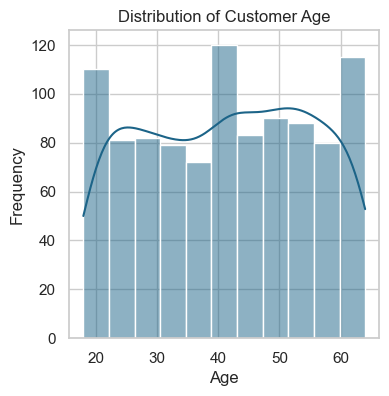

In [37]:
plt.figure(figsize=(4,4))
sns.histplot(df["Age"], kde=True, color=sns.color_palette("crest")[4])
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

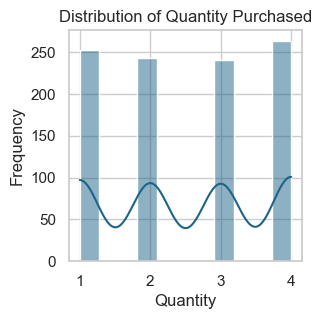

In [36]:
plt.figure(figsize=(3,3))
sns.histplot(df["Quantity"], kde=True, color=sns.color_palette("crest")[4])
plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

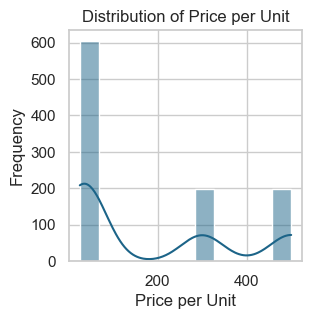

In [42]:
plt.figure(figsize=(3,3))
sns.histplot(df["Price per Unit"], kde=True, color=sns.color_palette("crest")[4])
plt.title("Distribution of Price per Unit")
plt.xlabel("Price per Unit")
plt.ylabel("Frequency")
plt.show()

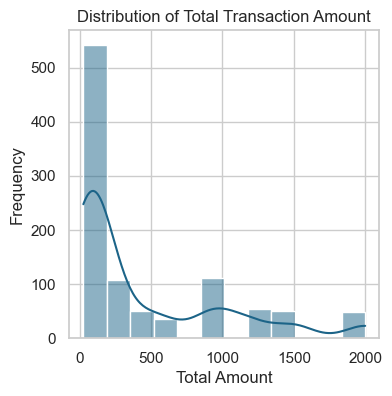

In [39]:
plt.figure(figsize=(4,4))
sns.histplot(df["Total Amount"], kde=True, color=sns.color_palette("crest")[4])
plt.title("Distribution of Total Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

### Exploration on Categorical Columns, Gender, Product Category, Month, Weekend

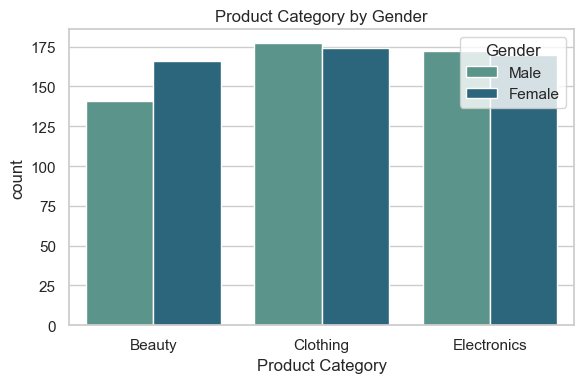

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Product Category",
    hue="Gender",
    palette="crest"
)

plt.title("Product Category by Gender")

plt.tight_layout()
plt.show()

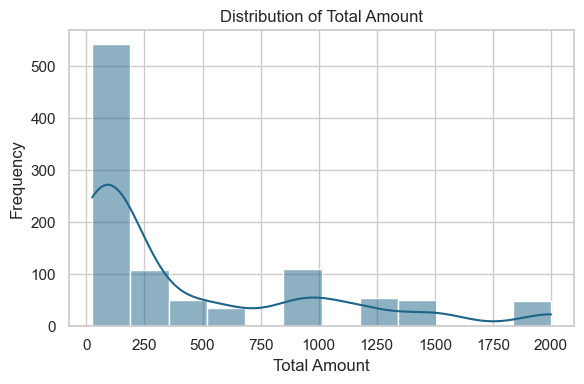

In [50]:
plt.figure(figsize=(6,4))

sns.histplot(
    df["Total Amount"],
    kde=True,
    color=sns.color_palette("crest")[4]
)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

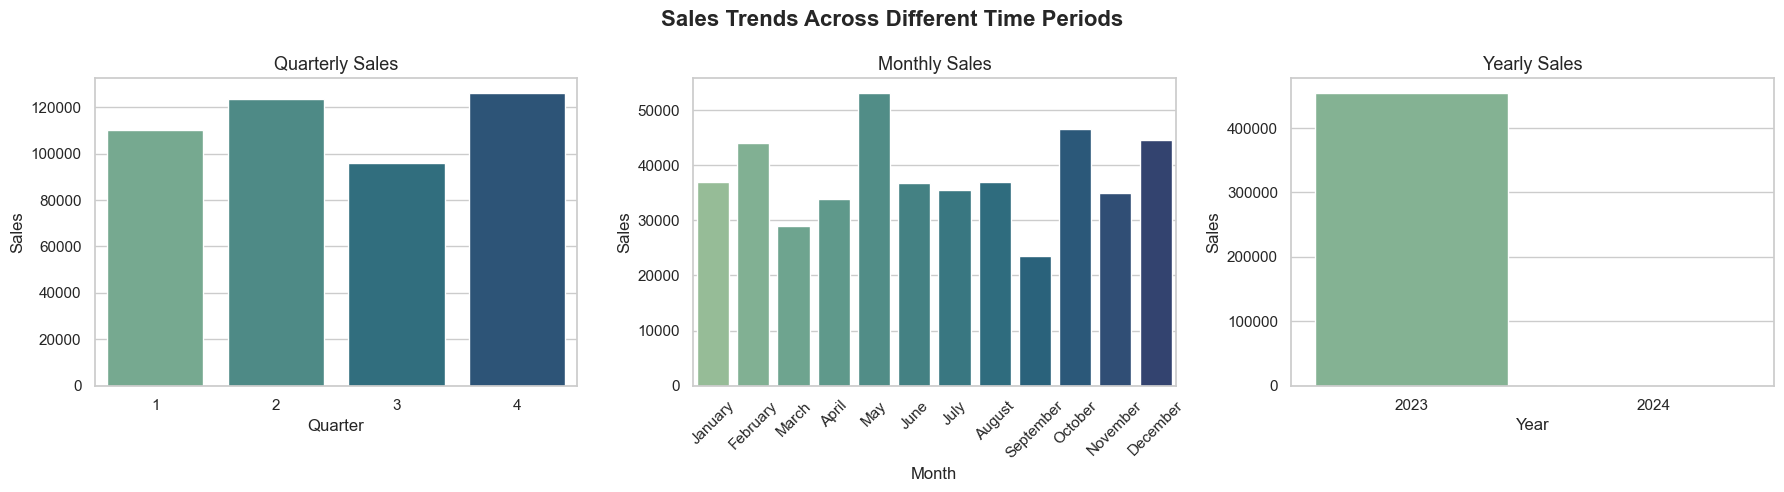

In [62]:
# Quarterly Sales
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum().reset_index()

# Monthly Sales
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = df.groupby("Month")["Total Amount"].sum().reset_index()

monthly_sales["Month"] = pd.Categorical(
    monthly_sales["Month"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values("Month")

# Yearly Sales
yearly_sales = df.groupby("Year")["Total Amount"].sum().reset_index()


# Create 3 graphs side by side
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ---------------- Quarter ----------------
sns.barplot(
    data=quarterly_sales,
    x="Quarter",
    y="Total Amount",
    palette="crest",
    ax=axes[0]
)

axes[0].set_title("Quarterly Sales", fontsize=13)
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Sales")

# ---------------- Month ----------------
sns.barplot(
    data=monthly_sales,
    x="Month",
    y="Total Amount",
    palette="crest",
    ax=axes[1]
)

axes[1].set_title("Monthly Sales", fontsize=13)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Sales")
axes[1].tick_params(axis='x', rotation=45)

# ---------------- Year ----------------
sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Total Amount",
    ax=axes[2]
)

axes[2].set_title("Yearly Sales", fontsize=13)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Sales")

# Overall Title
fig.suptitle(
    "Sales Trends Across Different Time Periods",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [59]:
print(yearly_sales)

   Year  Total Amount
0  2023        454470
1  2024          1530


## Insights
- Sales exhibit clear seasonal fluctuations, indicating that customer purchasing behavior changes throughout the year.
- Q4 is the strongest-performing quarter, making it a critical period for revenue generation.
- May, October, and December are high-performing months, while September represents a low-demand period.
- The presence of recurring peaks and dips suggests that businesses should adopt season-specific inventory planning, staffing, and marketing strategies rather than maintaining the same operational approach year-round.
- Since only one year's worth of complete data is available, the analysis focuses on intra-year seasonal patterns rather than long-term growth trends.

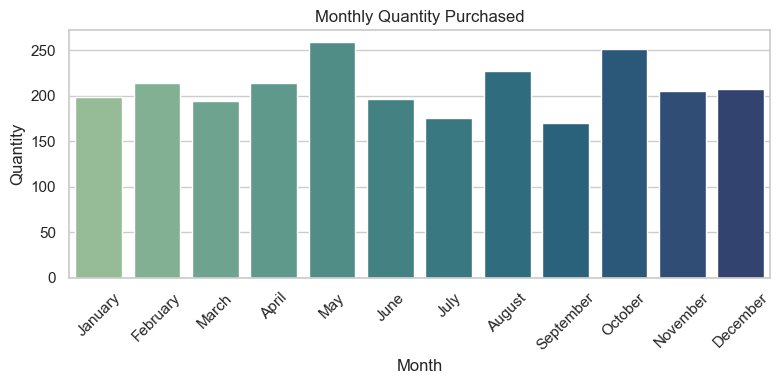

In [72]:
# Monthly Quantity Purchased

monthly_qty = (
    df.groupby("Month")["Quantity"]
    .sum()
    .reset_index()
)

monthly_qty["Month"] = pd.Categorical(
    monthly_qty["Month"],
    categories=month_order,
    ordered=True
)

monthly_qty = monthly_qty.sort_values("Month")

plt.figure(figsize=(8,4))

sns.barplot(
    data=monthly_qty,
    x="Month",
    y="Quantity",
    palette="crest"
)

plt.xticks(rotation=45)
plt.title("Monthly Quantity Purchased")
plt.tight_layout()
plt.show()

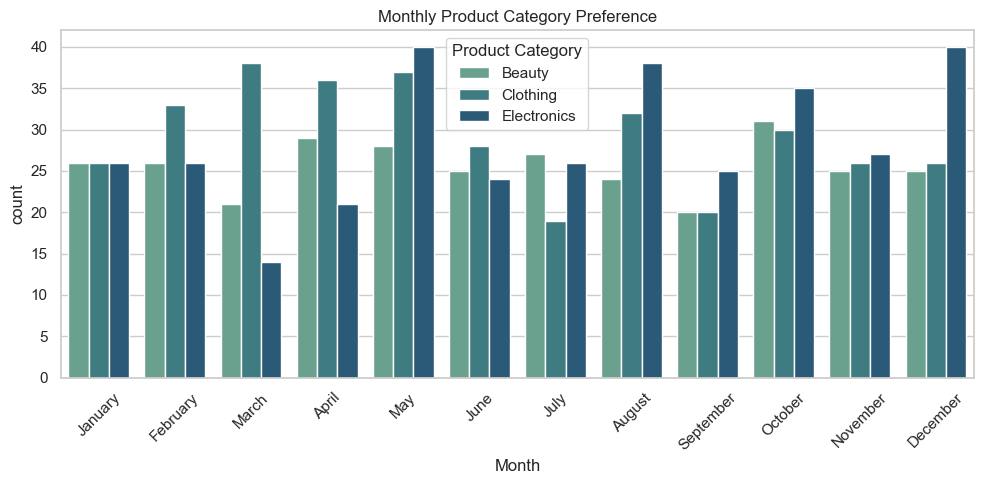

In [73]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Month",
    hue="Product Category",
    palette="crest",
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Monthly Product Category Preference")

plt.tight_layout()

plt.show()

### Insights:

- Customer preferences shift seasonally rather than remaining constant.
 - Clothing demand strengthens during the first half of the year.
- Electronics dominate towards the end of the year, likely due to holiday sales, festive offers, or promotional campaigns.
- Beauty products exhibit relatively consistent demand, making them less sensitive to seasonal fluctuations.
 - Customers tend to purchase more products during May and October, suggesting these are peak shopping periods.
- The lower purchase volumes in July and September may represent off-peak months where customer engagement declines.
- The strong recovery during October–December highlights the importance of seasonal demand planning.

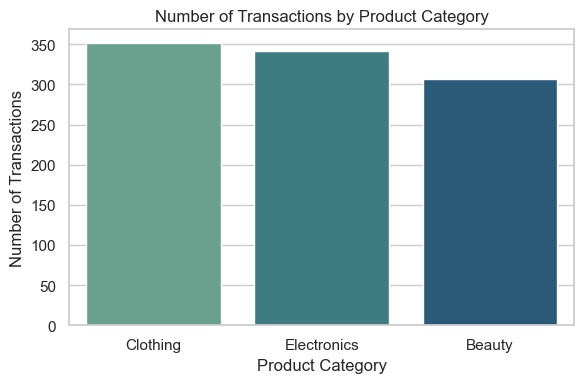

In [63]:
category_count = df["Product Category"].value_counts().reset_index()
category_count.columns = ["Product Category", "Number of Transactions"]

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Product Category",
    palette="crest",
    order=df["Product Category"].value_counts().index
)

plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Insights
 
 - Clothing recorded the highest number of transactions, making it the most frequently purchased product category among customers.
 - Electronics followed closely behind Clothing, indicating consistently high customer demand for electronic products.
 - Beauty had the lowest number of transactions among the three categories, suggesting comparatively lower purchase frequency.
 - The difference between Clothing and Electronics is relatively small, indicating that customer interest is almost evenly distributed between these two categories.
 - Although Beauty has the fewest transactions, the difference is not substantial, suggesting that all three categories maintain a healthy level of customer demand.

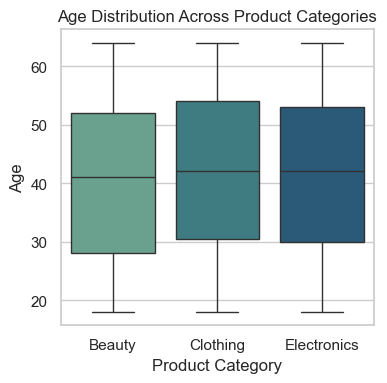

In [64]:
plt.figure(figsize=(4,4))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Age",
    palette="crest"
)

plt.title("Age Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

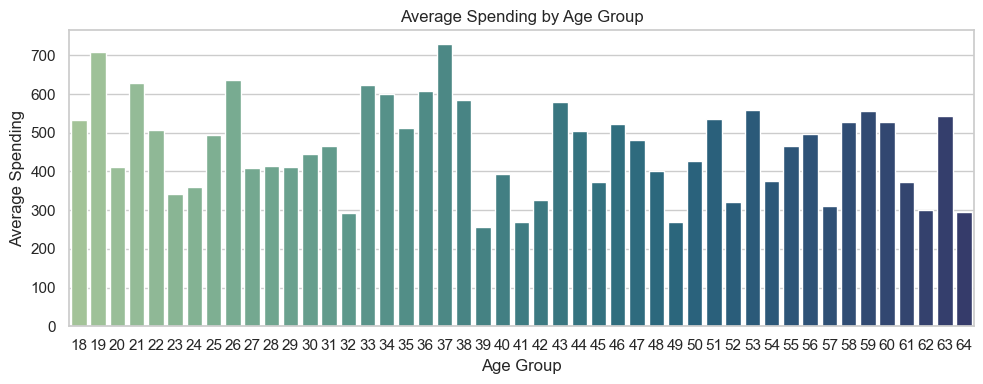

In [68]:
age_spending = (
    df.groupby("Age")["Total Amount"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,4))

sns.barplot(
    data=age_spending,
    x="Age",
    y="Total Amount",
    palette="crest"
)

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")

plt.tight_layout()
plt.show()

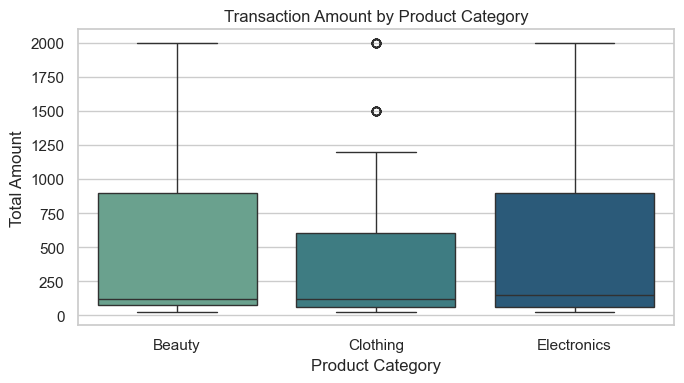

In [69]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Total Amount",
    palette="crest"
)

plt.title("Transaction Amount by Product Category")

plt.tight_layout()
plt.show()

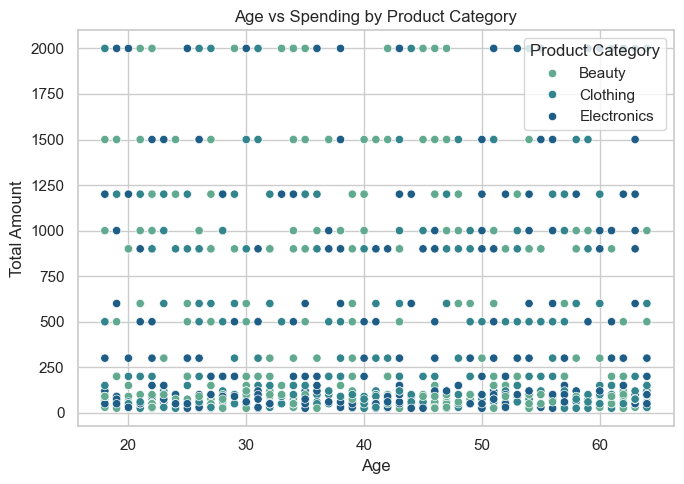

In [70]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total Amount",
    hue="Product Category",
    palette="crest"
)

plt.title("Age vs Spending by Product Category")

plt.tight_layout()

plt.show()

### Insights:

 - The retail business attracts customers across a diverse age range (18–64 years) for all product categories.
 - Age alone does not significantly influence product preference or spending behavior.
 - Transaction values vary more by individual purchase behavior than by customer age.
 - Electronics and Beauty exhibit greater variability in transaction values, suggesting opportunities for premium product strategies.
 - Product preferences appear broadly distributed across age groups, indicating that each category appeals to customers of different ages.

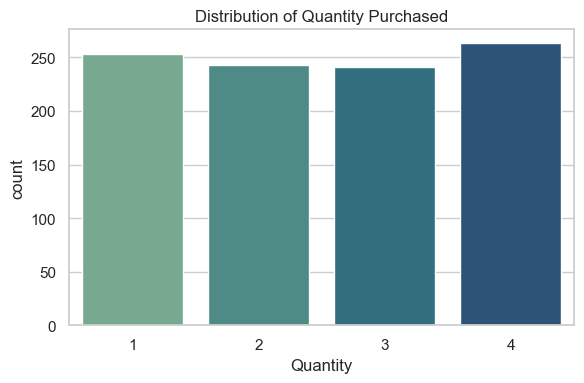

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Quantity",
    palette="crest"
)

plt.title("Distribution of Quantity Purchased")

plt.tight_layout()

plt.show()

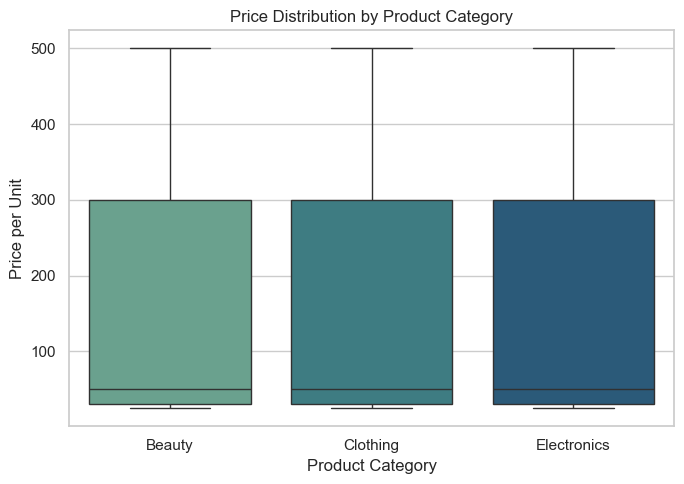

In [75]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Price per Unit",
    palette="crest"
)

plt.title("Price Distribution by Product Category")

plt.tight_layout()

plt.show()

###  Overall Summary

The exploratory data analysis of the retail sales dataset revealed several important patterns in customer purchasing behavior, product performance, and seasonal sales trends. Customer demand is not uniform throughout the year, with noticeable fluctuations in sales, transaction volume, and product preferences across different months and quarters.

Among the three product categories, Clothing recorded the highest number of transactions, indicating strong customer interest, while Electronics generated consistently high demand during peak shopping periods, particularly in the final quarter of the year. Beauty products maintained relatively stable demand throughout the year, suggesting a consistent customer base.

Seasonal analysis showed that Q4 was the strongest-performing quarter, with increased customer activity during October, November, and December, while Q3 experienced comparatively lower sales, highlighting a seasonal decline. Monthly analysis also revealed peaks in May and October, indicating periods of increased purchasing activity.

### Final Actionable Insights

1. Optimize Inventory Planning
Increase inventory levels for Electronics during October–December to meet higher seasonal demand.
Ensure sufficient stock for Clothing during March–May, when customer purchases are highest.
Maintain steady inventory for Beauty products, as demand remains relatively consistent throughout the year.

2. Improve Seasonal Marketing Strategies
Launch targeted promotional campaigns during July and September, when sales and purchase quantities decline.
Increase advertising budgets before Q4, where the business experiences its highest revenue potential.
Replicate successful promotional strategies used during May and October to drive customer engagement.

3. Enhance Customer Segmentation
Since age alone does not significantly influence purchasing behavior, segment customers using:
Purchase frequency
Average order value
Preferred product category
Shopping history
Use these segments to deliver personalized product recommendations and targeted marketing campaigns.

4. Maximize Revenue Opportunities
Promote premium products and upselling opportunities within the Electronics category, where transaction values show greater variability.
Introduce bundle offers and cross-selling strategies between Clothing and Beauty products to increase average basket size.
Monitor high-performing product categories and allocate marketing resources based on revenue contribution rather than transaction count alone.

5. Support Data-Driven Decision Making
Regularly monitor monthly and quarterly sales trends to improve demand forecasting.
Use historical sales data to anticipate seasonal fluctuations and optimize procurement and staffing.
Continuously evaluate category performance to identify emerging customer preferences and adjust product assortments accordingly.

### Final Recommendations

Based on the analysis, the following strategic recommendations are proposed:

- Prioritize inventory planning by aligning stock levels with seasonal demand, particularly during high-performing months and quarters.
 - Implement targeted marketing campaigns during low-demand periods to improve customer engagement and reduce seasonal sales fluctuations.
- Adopt customer behavior-based segmentation instead of relying solely on demographic information to create personalized shopping experiences.
- Focus on high-revenue product categories, especially Electronics, while using promotions and cross-selling techniques to improve the performance of lower-performing categories.
- Leverage historical sales data for demand forecasting, pricing optimization, and resource planning to improve operational efficiency.
- Develop interactive business dashboards to continuously monitor key performance indicators such as sales trends, category performance, customer spending, and seasonal demand.